This file constitutes the first attempt at implementing a Fourier neural operator in python. It is inspired by Zongyi Li's paper "Fourier Neural Operator for Parametric Partial Differential Equations", and the implementation is taken from the corresponding repository found here:

https://github.com/ixScience/fourier_neural_operator/blob/master/fourier_1d.py

In [5]:
from FNO1D_def import *   # <-- your 1D FNO definition file
import h5py
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import os

torch.manual_seed(0)
np.random.seed(0)

# =====================
# Config
# =====================
batch_size = 20
lr = 1e-3
epochs = 500
val_patience = 25

modes = 4          # 1D: only one modes argument
width = 64          # width of the hidden channels
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Path to ONE resolution (for training)
h5_path = "/scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N128_multi.h5"
dataset = "u"   # dataset key

# =====================
# Dataset
# =====================
class Heat1DDataset(torch.utils.data.Dataset):
    """
    Dataset for learning the direct mapping u0 -> uT from 2-frame trajectories.
    """

    def __init__(self, h5_path, split="train", split_ratio=(0.8, 0.2)):
        with h5py.File(h5_path, "r") as f:
            self.u = f[dataset][:]    # shape: (num_samples, 2, N)
            self.X = f["X"][:]

        self.num_samples = self.u.shape[0]
        n_train = int(self.num_samples * split_ratio[0])

        if split == "train":
            self.idxs = range(0, n_train)
        else:
            self.idxs = range(n_train, self.num_samples)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        i = self.idxs[idx]

        u_in  = self.u[i, 0, :]   # (N,)
        u_out = self.u[i, 1, :]   # (N,)

        # Add channel dim: (1, N)
        u_in  = torch.tensor(u_in,  dtype=torch.float32).unsqueeze(0)
        u_out = torch.tensor(u_out, dtype=torch.float32).unsqueeze(0)

        return u_in, u_out


# =====================
# Data loaders
# =====================
train_ds = Heat1DDataset(h5_path, split="train")
val_ds   = Heat1DDataset(h5_path, split="val")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


# =====================
# Model
# =====================
model = FNO1D(modes, width)      # Your 1D FNO definition
model.fc1 = torch.nn.Linear(width, 1)   # final projection to 1 output channel
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_loss = 1e12
epochs_no_improve = 0


# =====================
# Training loop
# =====================
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for u_in, u_out in train_loader:
        u_in  = u_in.to(device)       # (B,1,N)
        u_out = u_out.to(device)      # (B,1,N)

        optimizer.zero_grad()

        # FNO1D expects input shape (B,N,1)
        u = u_in.permute(0,2,1)                  # (B,N,1)
        grid = model.get_grid(u.shape, device)   # (B,N,1)
        inp = torch.cat([u, grid], dim=-1)       # (B,N,2)

        pred = model(inp)                        # (B,N,1)
        pred = pred.permute(0,2,1)               # → (B,1,N)

        loss = F.mse_loss(pred, u_out)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------------------
    # Validation
    # -------------------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for u_in, u_out in val_loader:
            u_in  = u_in.to(device)
            u_out = u_out.to(device)

            u = u_in.permute(0,2,1)                  # (B,N,1)
            grid = model.get_grid(u.shape, device)   # (B,N,1)
            inp = torch.cat([u, grid], dim=-1)       # (B,N,2)

            pred = model(inp)                        # (B,N,1)
            pred = pred.permute(0,2,1)               # → (B,1,N)
            val_loss += F.mse_loss(pred, u_out).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train {train_loss:.4e} | Val {val_loss:.4e}")

    # Early stopping
    if val_loss < best_val_loss * (1 - 1e-3):
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= val_patience:
            print("Early stop triggered.")
            break

print("Training complete. Best val loss:", best_val_loss)


/scratch/mnhagen/myenv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 000 | Train 3.6541e-02 | Val 3.8436e-03
Epoch 001 | Train 3.2748e-03 | Val 2.8803e-03
Epoch 002 | Train 2.8493e-03 | Val 2.7943e-03
Epoch 003 | Train 2.8147e-03 | Val 2.8013e-03
Epoch 004 | Train 2.8034e-03 | Val 2.7861e-03
Epoch 005 | Train 2.7961e-03 | Val 2.7867e-03
Epoch 006 | Train 2.7922e-03 | Val 2.7532e-03
Epoch 007 | Train 2.7791e-03 | Val 2.7514e-03
Epoch 008 | Train 2.7618e-03 | Val 2.7493e-03
Epoch 009 | Train 2.7198e-03 | Val 2.6701e-03
Epoch 010 | Train 2.6531e-03 | Val 2.6099e-03
Epoch 011 | Train 2.5642e-03 | Val 2.4507e-03
Epoch 012 | Train 2.3300e-03 | Val 2.2627e-03
Epoch 013 | Train 2.1281e-03 | Val 2.0675e-03
Epoch 014 | Train 1.8795e-03 | Val 1.7964e-03
Epoch 015 | Train 1.6628e-03 | Val 1.5439e-03
Epoch 016 | Train 1.4698e-03 | Val 1.3182e-03
Epoch 017 | Train 1.3170e-03 | Val 1.2340e-03
Epoch 018 | Train 1.2199e-03 | Val 1.1762e-03
Epoch 019 | Train 1.1420e-03 | Val 1.0841e-03
Epoch 020 | Train 1.0846e-03 | Val 1.0724e-03
Epoch 021 | Train 1.0558e-03 | Val

In [6]:
#Save model

model_dir = "/scratch/mnhagen/models/burgers/with_spatial"
model_name = f"FNO1D_heat_eq_128_modes{modes}"
model_path = os.path.join(model_dir, model_name + ".pt")
overwrite = True

os.makedirs(model_dir, exist_ok= True)

if not overwrite:
    if os.path.exists(model_path):
        raise FileExistsError(f"Model file already exists: {model_path}")

torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to /scratch/mnhagen/models/burgers/with_spatial/FNO1D_heat_eq_128_modes4.pt


In [5]:
#Load model for testing

model = FNO1D(modes, width).cuda()
model.load_state_dict(torch.load(model_path))
model.eval()
model_name = "FNO1D_burgers_1024_v1"

myloss = LpLoss(size_average = False)
print(f"Loaded model from {model_path}")

Loaded model from /scratch/mnhagen/models/burgers/with_spatial/FNO1D_burgers_1024_v1.pt


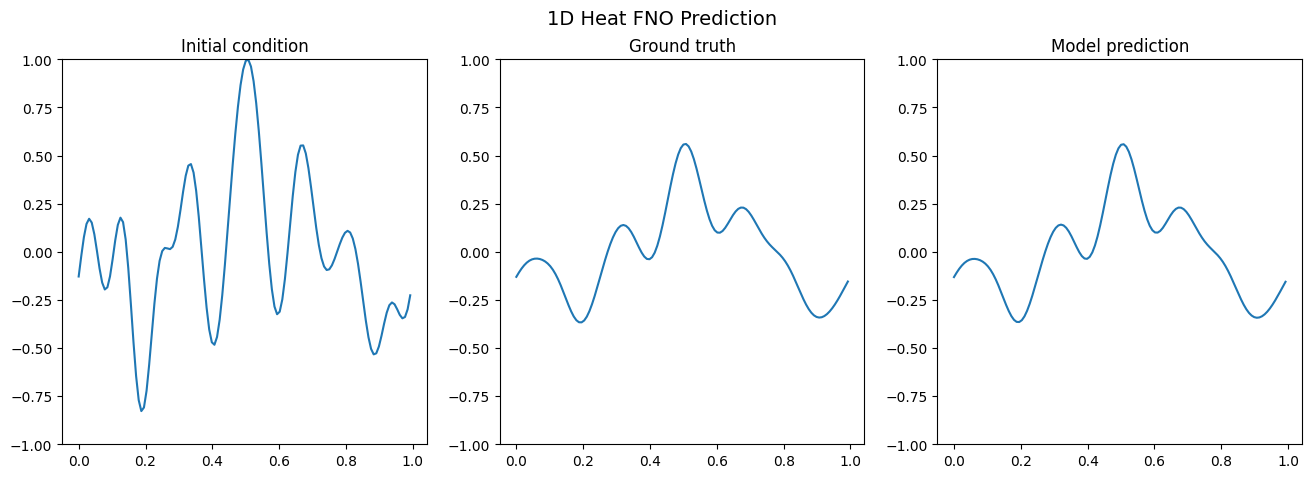

In [3]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# Helper: run the model on the validation set
# ---------------------------------------------
def evaluate_model(model, val_ds):
    model.eval()
    
    N = val_ds.u.shape[-1]       # spatial resolution N
    M = len(val_ds)              # number of samples in val set
    
    preds = np.zeros((M, N))

    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

    with torch.no_grad():
        for i, (u_in, u_out) in enumerate(val_loader):
            u_in = u_in.to(device)    # (1,1,N)

            # prepare input same as in training
            u = u_in.permute(0,2,1)   # (1,N,1)
            grid = model.get_grid(u.shape, device)
            inp = torch.cat([u, grid], dim=-1)

            pred = model(inp)         # (1,N,1)
            pred = pred.permute(0,2,1)  # -> (1,1,N)

            preds[i] = pred.cpu().numpy().reshape(N)

    return preds


# ------------------------------------------------
# Run prediction on full validation set
# ------------------------------------------------
pred = evaluate_model(model, val_ds)

# Choose sample to plot
plot_idx = 10

u_in, u_true = val_ds[plot_idx]      # each is (1,N)
u_in = u_in.squeeze().numpy()        # (N,)
u_true = u_true.squeeze().numpy()    # (N,)
u_pred = pred[plot_idx]              # (N,)

N = len(u_true)
x = np.linspace(0, 1, N, endpoint=False)

# ------------------------------------------------
# Plot
# ------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("1D Heat FNO Prediction", fontsize=14)

ax[0].plot(x, u_in)
ax[0].set_title("Initial condition")
ax[0].set_ylim(-1, 1)

ax[1].plot(x, u_true)
ax[1].set_title("Ground truth")
ax[1].set_ylim(-1, 1)

ax[2].plot(x, u_pred)
ax[2].set_title("Model prediction")
ax[2].set_ylim(-1, 1)

plt.show()

